In [1]:
from os import listdir
from os.path import isfile, join
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def getData(path="results/"):

    files = [join(path, f) for f in listdir(path) if isfile(join(path, f))]

    dataDict = {}

    count = 1
    goodFiles = []
    for file in files:
        arr = np.genfromtxt(file, delimiter=",")
        if arr.shape == (2,8):
            count += 1
            goodFiles.append(arr)

            name = file.split("/")[1].rstrip(".csv")
            dataDict[name] = [arr[0].tolist(), arr[1].tolist()]

    means = np.zeros(shape=(count, 8))
    stdvs = np.zeros(shape=(count, 8))

    for i, dat in enumerate(goodFiles):
        means[i] = dat[0]
        stdvs[i] = dat[1]

    return dataDict, [np.mean(means, axis=0).tolist(), np.mean(stdvs, axis=0).tolist()]

In [3]:
def plotFunction(data, name="all"):

    xes = ["1S", "2S", "3S", "4S", "4S'", "3S'", "2S'", "1S'"]
    means = data[0]
    stdvs = data[1]

    plt.style.use("default")
    plt.figure(figsize=(8, len(xes) * 0.8))
    plt.bar(xes, means, yerr=stdvs, capsize=5)
    if len(name) < 15:
        plt.suptitle(f"Degree of conservation of {name} substrate sequences", fontsize=16)
    else:
        plt.suptitle(f"Degree of conservation of\n{name}\nsubstrate sequences", fontsize=16)
    plt.title("Aligned positionwise", fontsize=12)
    plt.xlabel("Substrate aa position", fontsize=12)
    plt.ylabel("Degree of conservation", fontsize=12)

    for i, v in enumerate(means):
        ra = 45 if v >= 0 else -45
        va = 'bottom' if v >= 0 else 'top'
        plt.text(i, v, round(v, 3),
                 rotation=ra,
                 ha="right",
                 va=va)
    plt.tight_layout()
    plt.show()

In [4]:
def dataCounter(dataDict, fileName="cleavage_sites.fasta"):

    countDict = {}

    with open(fileName, "r") as fastaFile:
        for line in fastaFile:
            if line.startswith(">"):
                name = line.split(" | ")[1]
                if name in dataDict.keys():
                    if name not in countDict:
                        countDict[name] = 1
                    else:
                        countDict[name] += 1
    
    countDict = dict(sorted(countDict.items(), reverse=True, key=lambda item: item[1]))


    return countDict

In [5]:
dataDict, allData = getData()

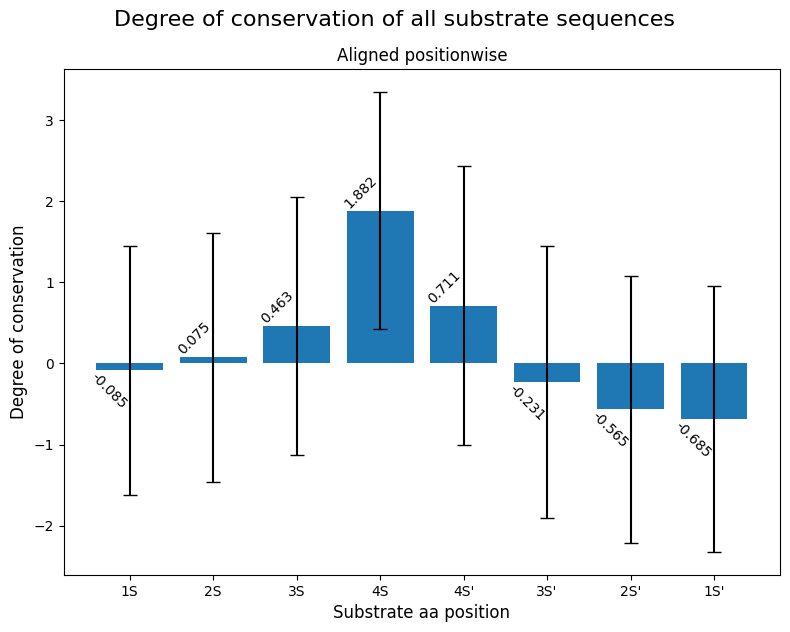

In [6]:
plotFunction(allData)

1) protease glutamyl endopeptidase I, with 4320 substrate sequences:


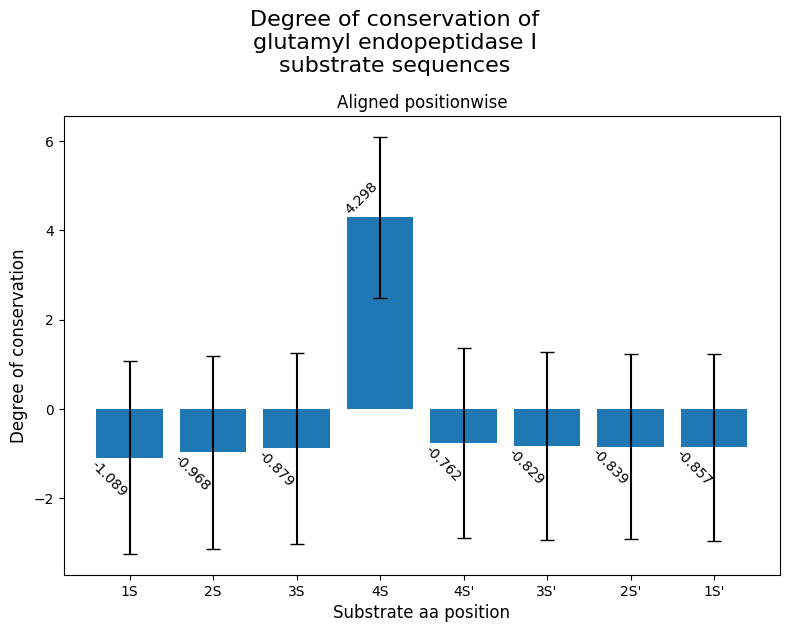


2) protease M24 homologue, with 3693 substrate sequences:


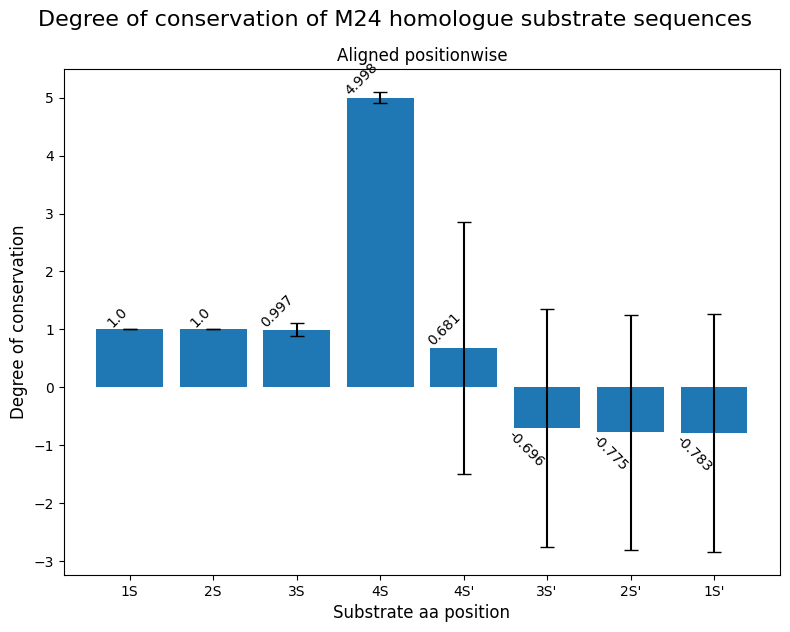


3) protease matrix metallopeptidase-2, with 3399 substrate sequences:


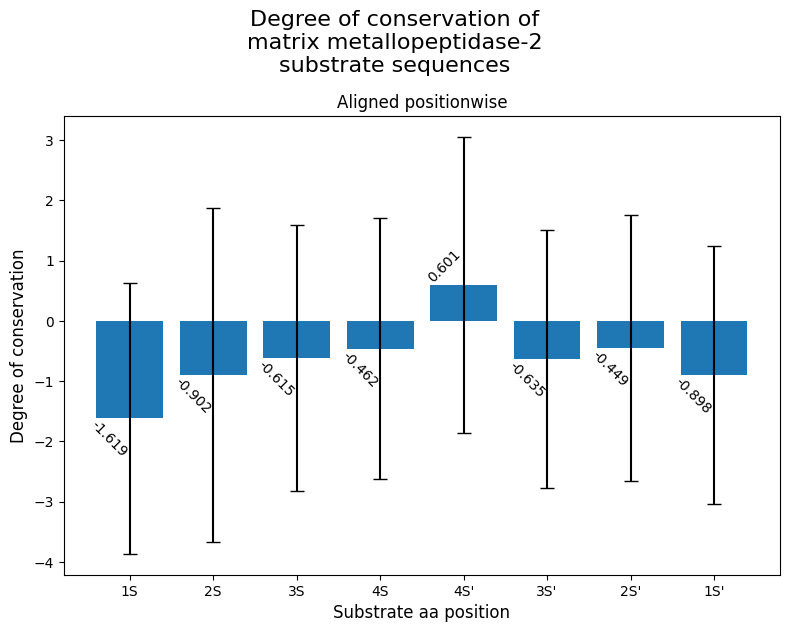


4) protease cathepsin S, with 3109 substrate sequences:


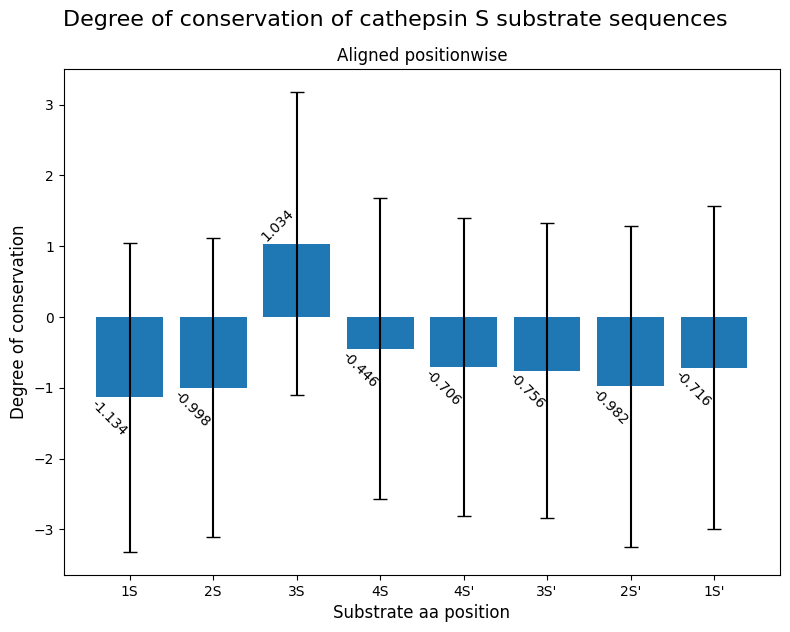


5) protease cathepsin L, with 2913 substrate sequences:


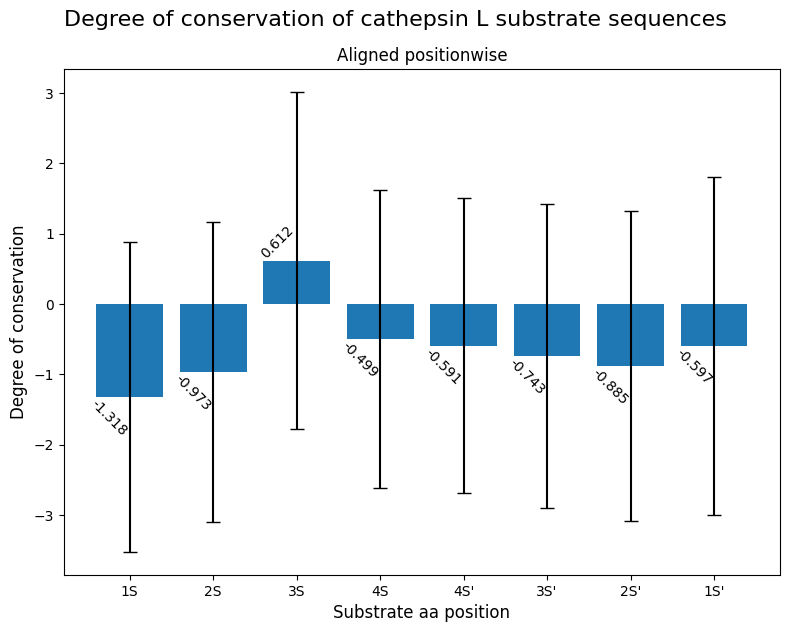

In [7]:
countedData = dataCounter(dataDict)

start = 1
stop = 5

for k, v in countedData.items():
    print(f"{start}) protease {k}, with {v} substrate sequences:")
    plotFunction(dataDict[k], k)
    print()

    if start == stop:
        break
    start += 1